## EPA/OPR best-fit chooser
Pick EPA or OPR per teammate so the alliance total tracks the official score.

Running the first code cell reads the OSF EPA export, the Statbotics OPR export, and the official match scores. It writes the selected values to `match.json` in the same event/match/teams shape as the raw exports.


In [7]:
from collections import Counter
from pathlib import Path
import json
from datetime import datetime, timezone
from itertools import product
from statistics import mean
import pandas as pd

epa_data_path = Path('orwil_epa_data.json')
opr_data_path = Path('2026orwil_opr_data.json')
scouting_data_path = Path('2026orwil_scouting_data(1).json')
match_data_path = Path('2026orwil_matches.json')
output_path = Path('orwilmatchmath(3).json')
print(output_path)

SCOUTING_POINT_MAP = {
    'auto_points': 'a_points',
    'tele_points': 'tele_fuel',
    'total_points': 'total_points',
    'tower_points': 'tower_points',
}
EPA_POINT_MAP = {
    'auto_points': 'auto_points',
    'tele_points': 'teleop_points',
    'total_points': 'total_points',
    'tower_points': 'total_tower',
}
OPR_POINT_MAP = {
    'auto_points': 'totalAutoPoints',
    'tele_points': 'totalTeleopPoints',
    'total_points': 'totalPoints',
    'tower_points': 'totalTowerPoints',
}

STAGE_KEYS = [
    ('auto', 'auto_points'),
    ('teleop', 'tele_points'),
    ('tower', 'tower_points'),
]

STAGE_SCORE_KEYS = {
    'auto': 'totalAutoPoints',
    'teleop': 'totalTeleopPoints',
    'tower': 'totalTowerPoints',
}
STAGE_NAMES = [stage for stage, _ in STAGE_KEYS]

def load_json(path):
    if not path.exists():
        raise FileNotFoundError(f'{path} is missing.')
    return json.loads(path.read_text())

def parse_team_key(team_key):
    if isinstance(team_key, str) and team_key.lower().startswith('frc'):
        return int(team_key[3:])
    return int(team_key)

def best_alignment(team_rows, target_score, target_stages):
    option_lists = []
    for row in team_rows:
        options = available_metrics_for_row(row)
        if not options:
            return None
        option_lists.append(options)
    if not option_lists or target_score is None:
        return None
    stage_names = STAGE_NAMES
    normalized_targets = {
        stage: (target_stages.get(stage) if target_stages else None)
        for stage in stage_names
    }
    best_combo = None
    best_combined_diff = float('inf')
    best_total = None
    best_total_diff = None
    best_stage_diffs = None
    for combo in product(*option_lists):
        total = sum(option['value'] for option in combo)
        total_diff = abs(total - target_score)
        stage_totals = {stage: 0.0 for stage in stage_names}
        for option in combo:
            stage_values = option.get('stage_values', {})
            for stage in stage_names:
                value = stage_values.get(stage)
                if value is None:
                    continue
                stage_totals[stage] += value
        stage_diff_sum = 0.0
        stage_diffs = {}
        for stage in stage_names:
            target_value = normalized_targets.get(stage)
            predicted_value = stage_totals.get(stage)
            if target_value is None or predicted_value is None:
                stage_diffs[stage] = None
                continue
            diff_value = abs(predicted_value - target_value)
            stage_diffs[stage] = diff_value
            stage_diff_sum += diff_value
        combined_diff = total_diff + stage_diff_sum
        if combined_diff < best_combined_diff or (
                combined_diff == best_combined_diff and (best_total is None or total < best_total)):
            best_combined_diff = combined_diff
            best_total = total
            best_total_diff = total_diff
            best_stage_diffs = stage_diffs
            best_combo = combo
    if best_combo is None:
        return None
    metrics_used = []
    for row, option in zip(team_rows, best_combo):
        stage_values = option.get('stage_values', {})
        row['selected_metric'] = option.get('metric')
        row['selected_value'] = option.get('value')
        auto_score = stage_values.get('auto')
        tele_score = stage_values.get('teleop')
        tower_score = stage_values.get('tower')
        row['selected_auto'] = auto_score
        row['selected_teleop'] = tele_score
        row['selected_tower'] = tower_score
        row['selected_total'] = option.get('value')
        metrics_used.extend(option.get('metrics', []))
    def format_diff(value):
        return round(value, 3) if value is not None else None
    return {
        'total': round(best_total, 3),
        'difference': round(best_combined_diff, 3),
        'total_difference': format_diff(best_total_diff),
        'auto_difference': (
            format_diff(best_stage_diffs.get('auto')) if best_stage_diffs else None
        ),
        'teleop_difference': (
            format_diff(best_stage_diffs.get('teleop')) if best_stage_diffs else None
        ),
        'tower_difference': (
            format_diff(best_stage_diffs.get('tower')) if best_stage_diffs else None
        ),
        'metrics': metrics_used,
    }

def map_points(metrics, mapping):
    if not metrics:
        return None
    mapped = {dest: metrics.get(src) for dest, src in mapping.items()}
    if any(value is not None for value in mapped.values()):
        return mapped
    return None

def compute_total_from_points(points):
    if not points:
        return None
    total = points.get('total_points')
    if total is not None:
        return total
    components = [points.get('auto_points'), points.get('tele_points'), points.get('tower_points')]
    if any(value is not None for value in components):
        return sum(value or 0.0 for value in components if value is not None)
    return None

def available_metrics_for_row(row):
    options = []
    points = row.get('points', {})
    match_number = row.get('match_number') or 0
    allow_opr_metrics = match_number > 42

    def stage_breakdown(metric_key):
        breakdown = points.get(metric_key) or {}
        return {
            'auto': safe_score(breakdown.get('auto_points')),
            'teleop': safe_score(breakdown.get('tele_points')),
            'tower': safe_score(breakdown.get('tower_points')),
        }

    def add_aggregated(metric_label, total_value):
        if total_value is None:
            return
        breakdown = stage_breakdown(metric_label)
        options.append({
            'metric': metric_label,
            'value': total_value,
            'metrics': [metric_label],
            'stage_values': {
                'auto': breakdown['auto'],
                'teleop': breakdown['teleop'],
                'tower': breakdown['tower'],
                'total': total_value,
            },
        })

    scouting_total = compute_total_from_points(points.get('scouting'))
    add_aggregated('scouting', scouting_total)

    epa_value = row.get('epa')
    if epa_value is None:
        epa_value = compute_total_from_points(points.get('epa'))
    add_aggregated('epa', epa_value)

    opr_value = row.get('opr')
    if allow_opr_metrics:
        add_aggregated('opr', opr_value)

    stage_candidates = []
    stage_metric_labels = ('scouting', 'epa', 'opr') if allow_opr_metrics else ('scouting', 'epa')
    for stage_name, stage_key in STAGE_KEYS:
        stage_options = []
        for metric_label in stage_metric_labels:
            breakdown = points.get(metric_label) or {}
            value = safe_score(breakdown.get(stage_key))
            if value is not None:
                stage_options.append({
                    'stage': stage_name,
                    'metric': metric_label,
                    'value': value,
                })
        if not stage_options:
            stage_candidates = []
            break
        stage_candidates.append(stage_options)

    if stage_candidates:
        for combo in product(*stage_candidates):
            stage_values = {choice['stage']: choice['value'] for choice in combo}
            total = sum(choice['value'] for choice in combo)
            options.append({
                'metric': 'stage_combo',
                'value': total,
                'metrics': sorted({choice['metric'] for choice in combo}),
                'stage_values': {
                    'auto': stage_values.get('auto'),
                    'teleop': stage_values.get('teleop'),
                    'tower': stage_values.get('tower'),
                    'total': total,
                },
            })

    return options


def safe_int(value, default=0):
    try:
        return int(value)
    except (TypeError, ValueError):
        return default

def safe_score(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None

epa_data = load_json(epa_data_path)
opr_data = load_json(opr_data_path)
scouting_data = load_json(scouting_data_path)
matches = load_json(match_data_path)

qual_matches = [match for match in matches if match.get('comp_level') == 'qm']

def match_sort_key(match):
    return (safe_int(match.get('set_number'), 0), safe_int(match.get('match_number'), 0))

qual_matches_sorted = sorted(qual_matches, key=match_sort_key)
team_played_counts = Counter()
match_order_info = []
for match in qual_matches_sorted:
    team_ids = []
    for alliance in ('red', 'blue'):
        team_keys = match.get('alliances', {}).get(alliance, {}).get('team_keys', []) or []
        for team_key in team_keys:
            team_ids.append(parse_team_key(team_key))
    allowed_opr = {team_id: team_played_counts[team_id] >= 8 for team_id in team_ids}
    match_order_info.append({
        'match': match,
        'team_ids': team_ids,
        'allowed_opr': allowed_opr,
    })
    for team_id in team_ids:
        team_played_counts[team_id] += 1

match_team_stats = {}
for record in scouting_data.get('matches', []):
    match_key = record['match_key']
    bucket = match_team_stats.setdefault(match_key, {})
    for team in record.get('teams', []):
        team_id = int(team['team'])
        team_stats = bucket.setdefault(team_id, {})
        points = map_points(team.get('metrics'), SCOUTING_POINT_MAP)
        if points:
            team_stats.setdefault('points', {})['scouting'] = points

for record in epa_data.get('matches', []):
    match_key = record['match_key']
    bucket = match_team_stats.setdefault(match_key, {})
    for team in record.get('teams', []):
        team_id = int(team['team'])
        team_stats = bucket.setdefault(team_id, {})
        epa_obj = team.get('epa', {})
        epa_value = epa_obj.get('post_match_total') or epa_obj.get('pre_match_total')
        if epa_value is not None:
            team_stats['epa'] = epa_value
        points = map_points(epa_obj.get('breakdown', {}), EPA_POINT_MAP)
        if points:
            team_stats.setdefault('points', {})['epa'] = points

for record in opr_data.get('matches', []):
    match_key = record['match_key']
    bucket = match_team_stats.setdefault(match_key, {})
    for team in record.get('teams', []):
        team_id = int(team['team'])
        team_stats = bucket.setdefault(team_id, {})
        opr_value = team.get('opr')
        if opr_value is not None:
            team_stats['opr'] = opr_value
        points = map_points(team.get('copr'), OPR_POINT_MAP)
        if points:
            team_stats.setdefault('points', {})['opr'] = points

matches_output = []
merged_diff_rows = []
metric_usage = Counter()
for info in match_order_info:
    match = info['match']
    match_key = match.get('key')
    if not match_key:
        continue
    alliances_data = {}
    team_rows = []
    stats_for_match = match_team_stats.get(match_key, {})
    allowed_opr = info['allowed_opr']
    for alliance in ('red', 'blue'):
        alliance_info = match.get('alliances', {}).get(alliance, {})
        score = alliance_info.get('score')
        team_keys = alliance_info.get('team_keys', []) or []
        alliance_rows = []
        for team_key in team_keys:
            team_id = parse_team_key(team_key)
            stats = stats_for_match.get(team_id, {})
            alliance_rows.append({
                'team_key': team_key,
                'team': team_id,
                'alliance': alliance,
                'epa': stats.get('epa'),
                'opr': stats.get('opr') if allowed_opr.get(team_id) else None,
                'points': stats.get('points', {}),
                'match_number': safe_int(match.get('match_number')),
            })
        breakdown = match.get('score_breakdown', {}).get(alliance, {})
        stage_targets = {
            stage: safe_score(breakdown.get(STAGE_SCORE_KEYS[stage]))
            for stage in STAGE_SCORE_KEYS
        }
        best = best_alignment(alliance_rows, score, stage_targets)
        if best is not None:
            metric_usage.update(best['metrics'])
        if best is None:
            for row in alliance_rows:
                row['selected_metric'] = None
                row['selected_value'] = None
                row['selected_total'] = None
                row['selected_auto'] = None
                row['selected_teleop'] = None
                row['selected_tower'] = None
        alliances_data[alliance] = {
            'score': score,
            'selected_total': best['total'] if best else None,
            'total_difference': best['total_difference'] if best else None,
            'auto_difference': best['auto_difference'] if best else None,
            'teleop_difference': best['teleop_difference'] if best else None,
            'tower_difference': best['tower_difference'] if best else None,
            'difference': best['difference'] if best else None,
            'selected_metrics': best['metrics'] if best else None,
        }
        team_rows.extend(alliance_rows)
    matches_output.append({
        'match_key': match_key,
        'event_key': match.get('event_key'),
        'set_number': match.get('set_number'),
        'match_number': match.get('match_number'),
        'time': match.get('time'),
        'status': 'completed' if match.get('post_result_time') else 'scheduled',
        'winning_alliance': match.get('winning_alliance'),
        'alliances': alliances_data,
        'teams': team_rows,
    })
    diffs = []
    for alliance_data in alliances_data.values():
        diff = alliance_data.get('difference')
        if diff is not None:
            diffs.append(abs(diff))
    if diffs:
        merged_diff_rows.append({
            'match_key': match_key,
            'match_number': safe_int(match.get('match_number')),
            'comp_level': match.get('comp_level'),
            'difference': mean(diffs),
        })

output_data = {
    'event': epa_data.get('event') or (qual_matches_sorted[0].get('event_key') if qual_matches_sorted else 'unknown-event'),
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'sources': {
        'epa': epa_data_path.name,
        'opr': opr_data_path.name,
        'scouting': scouting_data_path.name,
        'matches': match_data_path.name,
    },
    'matches': matches_output,
}
output_path.write_text(json.dumps(output_data, indent=2))

differences = [
    alliance['difference']
    for match in matches_output
    for alliance in match['alliances'].values()
    if alliance['difference'] is not None
]
print(f'Wrote {len(matches_output)} matches to {output_path.name}')
if differences:
    print(f'mean gap {sum(differences)/len(differences):.2f}, max gap {max(differences):.2f}')
else:
    print('No alliances had enough data to compare yet.')

actual_matches = {info['match'].get('key'): info['match'] for info in match_order_info if info['match'].get('key')}

def collect_diffs(predictions):
    getter = getattr(predictions, 'get', None)
    if getter is None or not callable(getter):
        getter = predictions
    rows = []
    for match_key, actual in actual_matches.items():
        predicted = getter(match_key)
        if not predicted:
            continue
        alliance_diffs = []
        for alliance, actual_info in actual['alliances'].items():
            score = safe_score(actual_info.get('score'))
            if score is None:
                continue
            pred_value = predicted.get(alliance)
            if pred_value is None:
                continue
            alliance_diffs.append(abs(pred_value - score))
        if not alliance_diffs:
            continue
        rows.append({
            'match_key': match_key,
            'match_number': int(actual['match_number']),
            'comp_level': actual.get('comp_level'),
            'difference': mean(alliance_diffs),
        })
    return rows

scouting_by_match = {
    record['match_key']: record
    for record in scouting_data.get('matches', [])
    if record.get('match_key')
}

scouting_predictions = {}
for match_key, match in actual_matches.items():
    scouting_match = scouting_by_match.get(match_key)
    if not scouting_match:
        continue
    totals = {'red': 0.0, 'blue': 0.0}
    seen = {'red': False, 'blue': False}
    for team in scouting_match.get('teams', []):
        alliance = team.get('alliance')
        points = map_points(team.get('metrics'), SCOUTING_POINT_MAP)
        total_amount = compute_total_from_points(points)
        if total_amount is not None:
            totals[alliance] += total_amount
            seen[alliance] = True
    aggregated = {alliance: (totals[alliance] if seen[alliance] else None) for alliance in totals}
    if any(seen.values()):
        scouting_predictions[match_key] = aggregated

epa_predictions = {}
for record in epa_data.get('matches', []):
    match_key = record.get('match_key')
    if match_key not in actual_matches:
        continue
    totals = {'red': 0.0, 'blue': 0.0}
    seen = {'red': False, 'blue': False}
    for team in record.get('teams', []):
        alliance = team.get('alliance')
        epa_total = team.get('epa', {}).get('pre_match_total') or team.get('epa', {}).get('post_match_total')
        if epa_total is not None:
            totals[alliance] += epa_total
            seen[alliance] = True
    aggregated = {alliance: (totals[alliance] if seen[alliance] else None) for alliance in totals}
    if any(seen.values()):
        epa_predictions[match_key] = aggregated

opr_predictions = {}
opr_matches = {
    record['match_key']: record
    for record in opr_data.get('matches', [])
    if record.get('match_key')
}
for info in match_order_info:
    match_key = info['match'].get('key')
    if not match_key or match_key not in actual_matches:
        continue
    allowed = info['allowed_opr']
    if not allowed or not all(allowed.values()):
        continue
    opr_match = opr_matches.get(match_key)
    if not opr_match:
        continue
    totals = {'red': 0.0, 'blue': 0.0}
    seen = {'red': False, 'blue': False}
    for team in opr_match.get('teams', []):
        alliance = team.get('alliance')
        opr_value = team.get('opr')
        if opr_value is not None:
            totals[alliance] += opr_value
            seen[alliance] = True
    aggregated = {alliance: (totals[alliance] if seen[alliance] else None) for alliance in totals}
    if any(seen.values()):
        opr_predictions[match_key] = aggregated

difference_records = []

def describe_dataset(label, entries):
    if not entries:
        print(f"{label}: no data")
        return
    sorted_entries = sorted(entries, key=lambda row: (safe_int(row.get('match_number')), row.get('match_key')))
    values = [row['difference'] for row in sorted_entries]
    print(f"{label}: mean gap {mean(values):.2f}, max gap {max(values):.2f}")
    for record in sorted_entries:
        actual = actual_matches.get(record['match_key'], {})
        difference_records.append({
            **record,
            'source': label,
            'match_json': json.dumps(actual),
            'alliances_json': json.dumps(actual.get('alliances', {})),
            'teams_json': json.dumps(actual.get('teams', [])),
        })
        print(f"  {label} {record['match_key']} (match {record['match_number']}): diff {record['difference']:.2f}")

dataset_entries = [
    ('Scouting totals', collect_diffs(scouting_predictions)),
    ('TBA (Orwil pre-match EPA)', collect_diffs(epa_predictions)),
    ('Statbotics (OPR)', collect_diffs(opr_predictions)),
    ('Merged selection', merged_diff_rows),
]

for label, entries in dataset_entries:
    describe_dataset(label, entries)

print('Metric usage counts:')
for metric, count in metric_usage.most_common():
    print(f"  {metric}: {count}")

export_matches_csv = True
matches_csv_path = Path('match_data.csv')
if export_matches_csv:
    rows = []
    for match in matches_output:
        row = {
            'event': output_data['event'],
            'generated_at': output_data['generated_at'],
            'source_epa': output_data['sources']['epa'],
            'source_opr': output_data['sources']['opr'],
            'source_scouting': output_data['sources']['scouting'],
            'source_matches': output_data['sources']['matches'],
            'match_key': match.get('match_key'),
            'event_key': match.get('event_key'),
            'set_number': match.get('set_number'),
            'match_number': match.get('match_number'),
            'time': match.get('time'),
            'status': match.get('status'),
            'winning_alliance': match.get('winning_alliance'),
            'alliances': json.dumps(match.get('alliances', {})),
            'teams': json.dumps(match.get('teams', [])),
        }
        rows.append({**row, 'match_json': json.dumps(match)})
    pd.DataFrame(rows).to_csv(matches_csv_path, index=False)
    print(f"Saved match data to {matches_csv_path}")

if difference_records:
    pd.DataFrame(difference_records).to_csv(Path('difference_data.csv'), index=False)
    print("Saved difference data to difference_data.csv")






orwilmatchmath(3).json
Wrote 64 matches to orwilmatchmath(3).json
mean gap 30.34, max gap 216.77
Scouting totals: mean gap 69.73, max gap 254.85
  Scouting totals 2026orwil_qm1 (match 1): diff 38.78
  Scouting totals 2026orwil_qm2 (match 2): diff 106.56
  Scouting totals 2026orwil_qm3 (match 3): diff 99.64
  Scouting totals 2026orwil_qm4 (match 4): diff 71.06
  Scouting totals 2026orwil_qm5 (match 5): diff 23.76
  Scouting totals 2026orwil_qm6 (match 6): diff 99.98
  Scouting totals 2026orwil_qm7 (match 7): diff 254.85
  Scouting totals 2026orwil_qm8 (match 8): diff 78.78
  Scouting totals 2026orwil_qm9 (match 9): diff 41.24
  Scouting totals 2026orwil_qm10 (match 10): diff 85.69
  Scouting totals 2026orwil_qm11 (match 11): diff 22.50
  Scouting totals 2026orwil_qm12 (match 12): diff 85.31
  Scouting totals 2026orwil_qm13 (match 13): diff 92.97
  Scouting totals 2026orwil_qm14 (match 14): diff 45.46
  Scouting totals 2026orwil_qm15 (match 15): diff 27.62
  Scouting totals 2026orwil_qm1

In [8]:
import json
from pathlib import Path
print("t")
output_path = Path('orwilmatchmath.json')
if not output_path.exists():
    raise FileNotFoundError('Run the previous cell to produce match.json first.')
data = json.loads(output_path.read_text())
print(f"{len(data.get('matches', []))} matches stored, each match carries {len(data['matches'][0].get('teams', [])) if data.get('matches') else 0} team entries.")
if data.get('matches'):
    sample = data['matches'][0]
    print('First match summary:')
    print(json.dumps({
        'match_key': sample['match_key'],
        'alliances': sample['alliances'],
        'teams': sample['teams'][:3],
    }, indent=2))


t
64 matches stored, each match carries 6 team entries.
First match summary:
{
  "match_key": "2026orwil_qm1",
  "alliances": {
    "red": {
      "score": 52,
      "selected_total": 51.992,
      "difference": 0.008,
      "selected_metrics": [
        "epa",
        "epa",
        "scouting",
        "epa",
        "scouting"
      ]
    },
    "blue": {
      "score": 131,
      "selected_total": 131.057,
      "difference": 0.057,
      "selected_metrics": [
        "epa",
        "scouting",
        "epa",
        "scouting",
        "epa"
      ]
    }
  },
  "teams": [
    {
      "team_key": "frc2635",
      "team": 2635,
      "alliance": "red",
      "epa": 36.29,
      "opr": null,
      "points": {
        "scouting": {
          "auto_points": 0.0,
          "tele_points": 0.0,
          "total_points": 0.0,
          "tower_points": 0.0
        },
        "epa": {
          "auto_points": 8.41,
          "tele_points": 20.59,
          "total_points": 38.55,
          "t

TBA (OPR): mean difference 23.12, max difference 106.08
Statbotics (Orwil pre-match EPA): mean difference 44.72, max difference 197.02
scouting totals: mean difference 69.73, max difference 421.88
Merged selection: mean difference 6.35, max difference 77.83


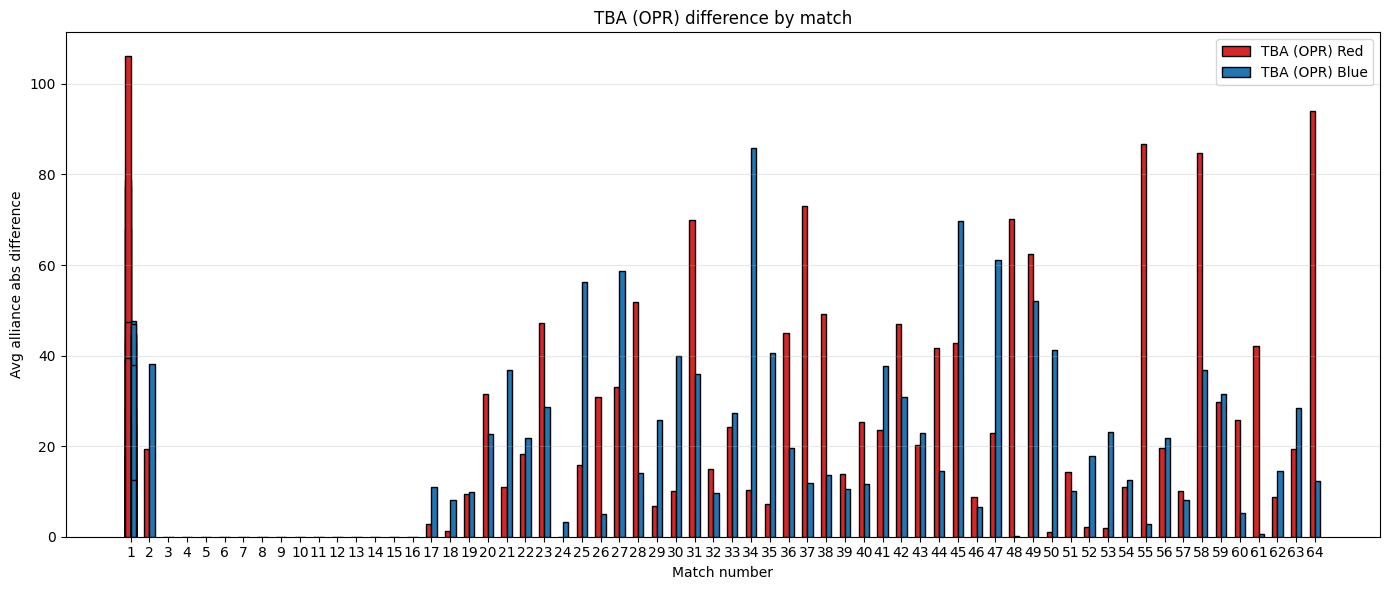

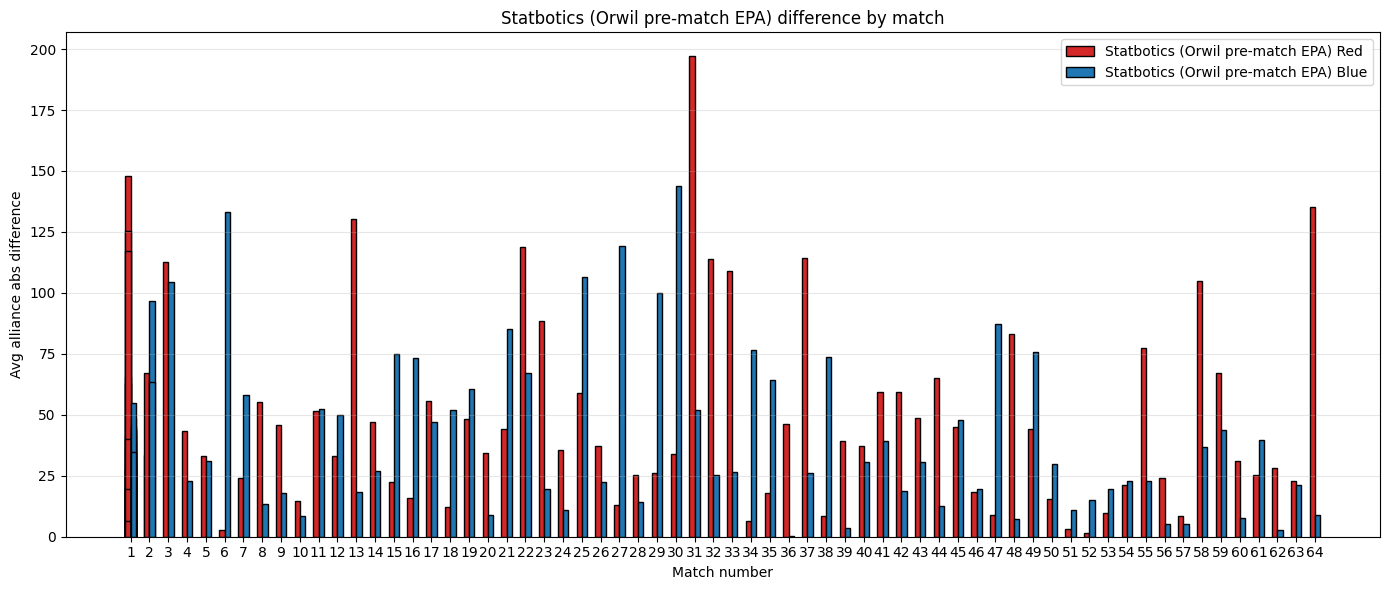

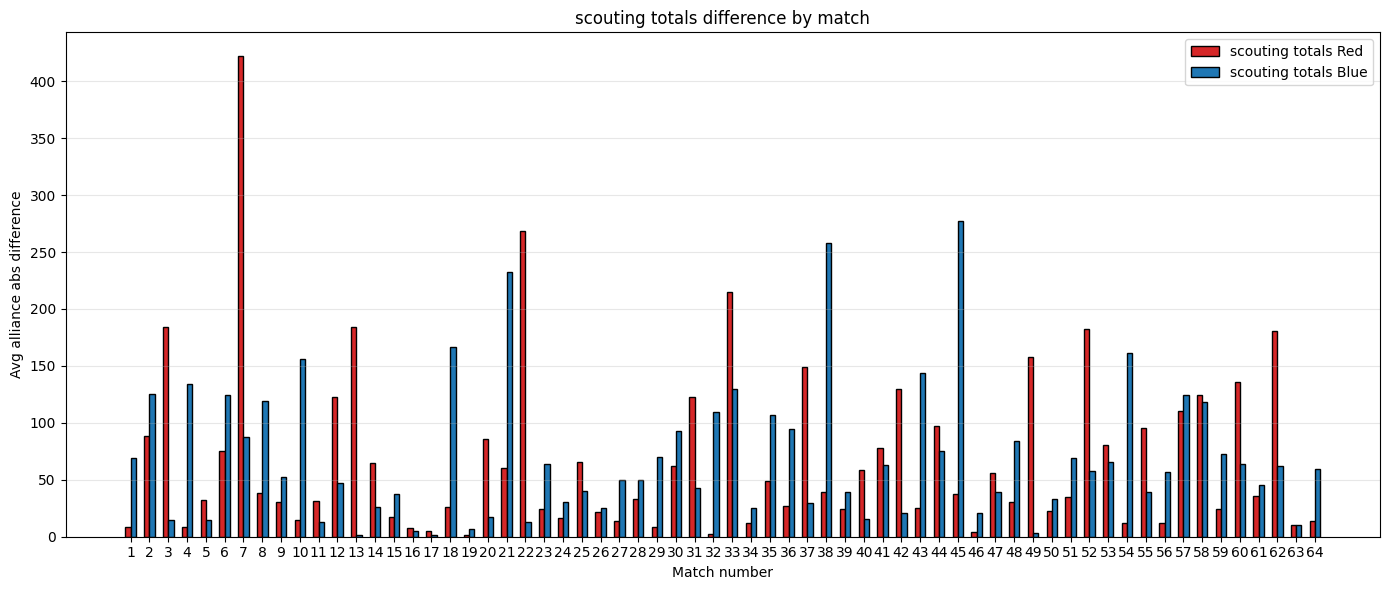

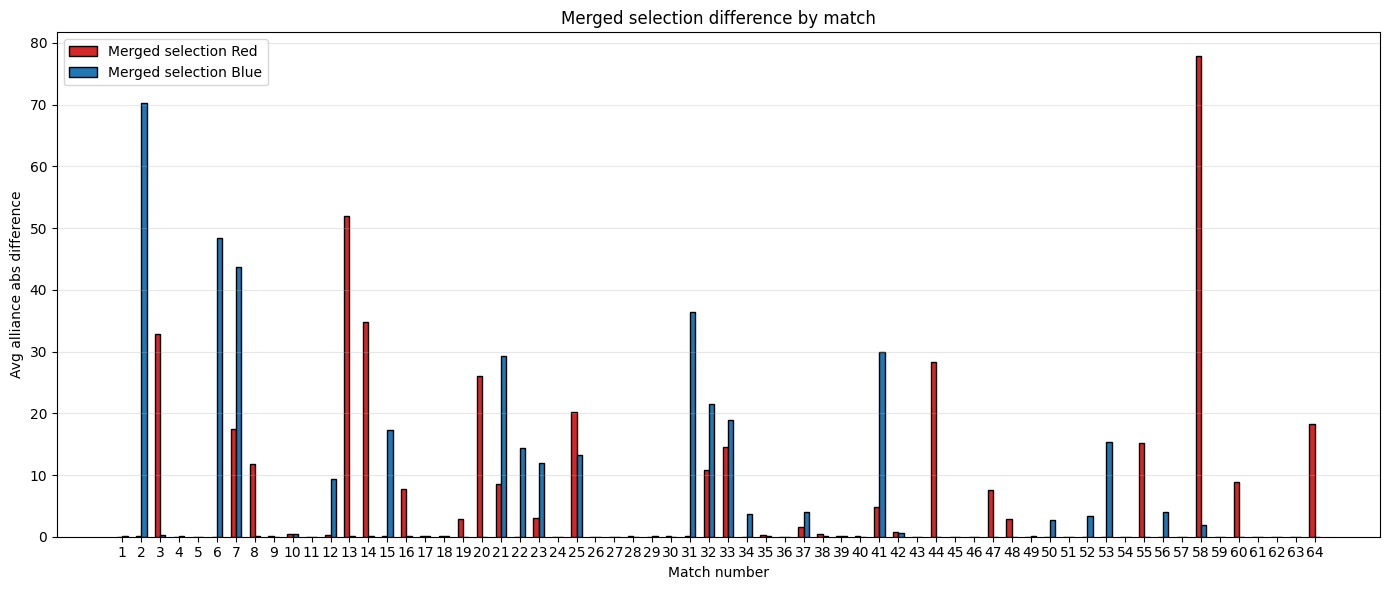

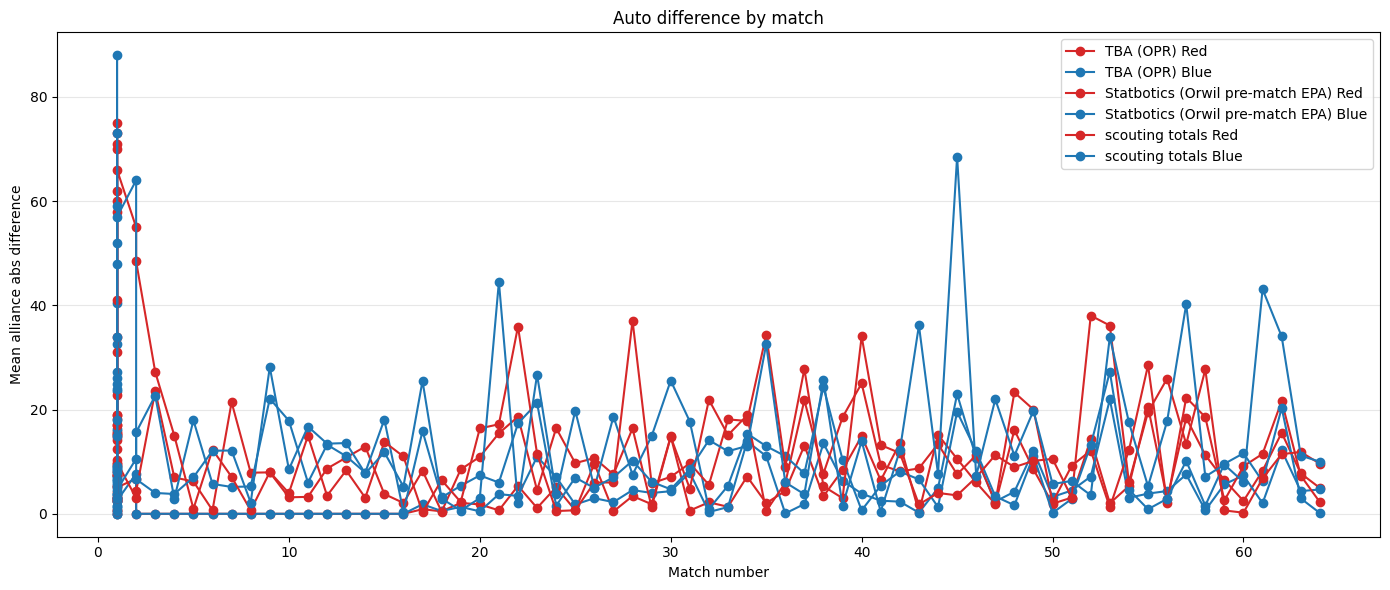

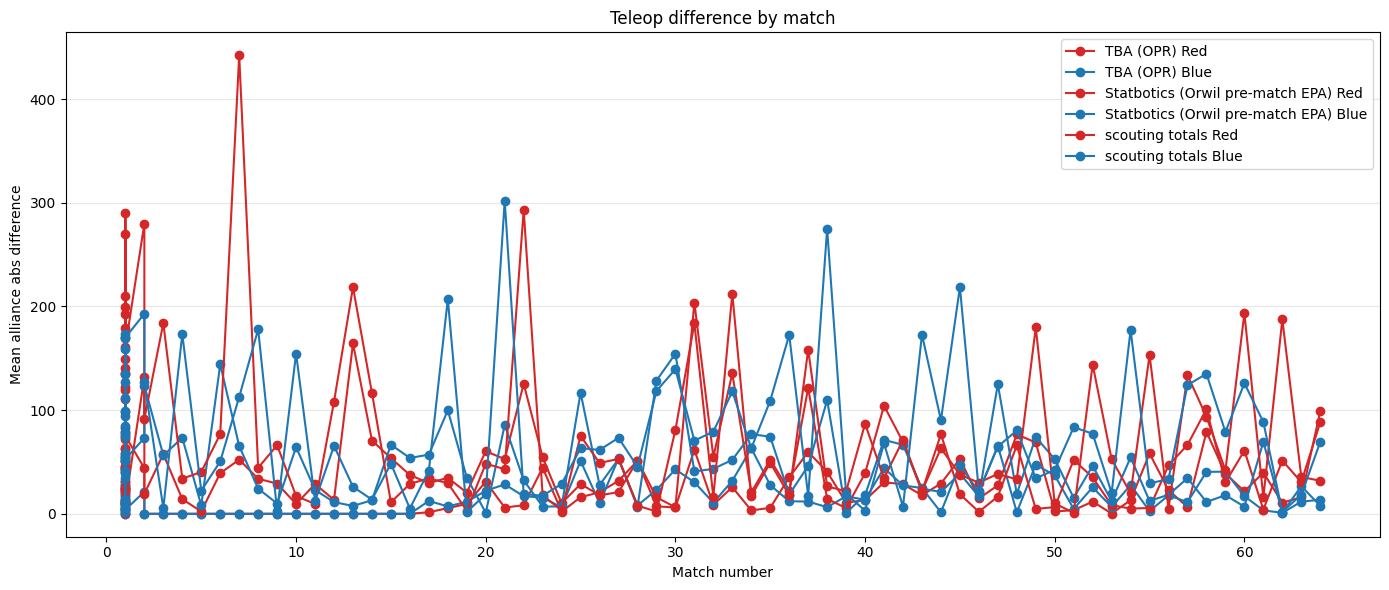

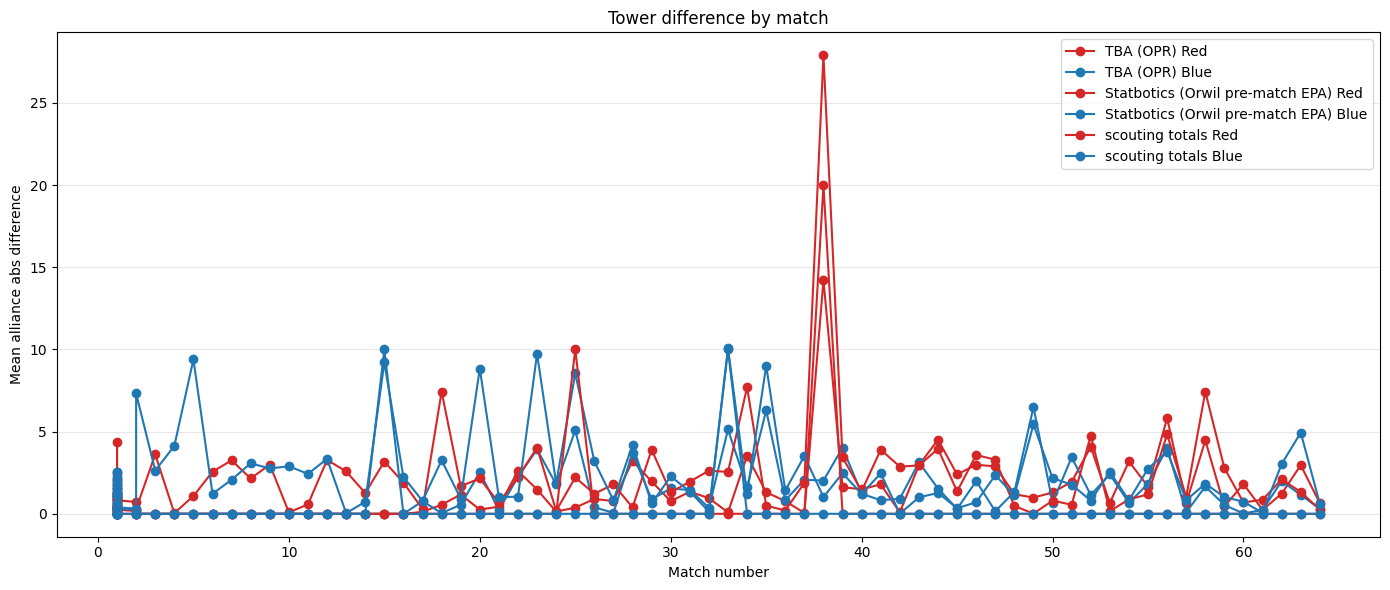

In [9]:
import json
from pathlib import Path
from statistics import mean

import matplotlib.pyplot as plt
import pandas as pd

match_order = {'qm': 0, 'sf': 1, 'f': 2}
export_to_csv = False
csv_path = Path('difference_data.csv')

ALLIANCE_COLORS = {'red': '#d62728', 'blue': '#1f77b4'}
BAR_WIDTH = 0.28
ALLIANCE_OFFSETS = {'red': -BAR_WIDTH / 2, 'blue': BAR_WIDTH / 2}

def load_json(path):
    return json.loads(Path(path).read_text())

actual_matches = {match['key']: match for match in load_json('2026orwil_matches.json')}
osf_matches = {match['match_key']: match for match in load_json('orwil_epa_data.json')['matches']}
opr_matches = {match['match_key']: match for match in load_json('2026orwil_opr_data.json')['matches']}
merged_matches = {match['match_key']: match for match in load_json('orwilmatchmath.json')['matches']}



scouting_matches = {
    record['match_key']: record
    for record in load_json('2026orwil_scouting_data.json').get('matches', [])
    if record.get('match_key')
}

SCOUTING_POINT_MAP = {
    'auto_points': 'a_points',
    'tele_points': 'tele_fuel',
    'tower_points': 'tower_points',
}

SCOUTING_STAGE_KEYS = {
    'auto': 'auto_points',
    'teleop': 'tele_points',
    'tower': 'tower_points',
}

EPA_STAGE_KEYS = {
    'auto': 'auto_points',
    'teleop': 'teleop_points',
    'tower': 'total_tower',
}

OPR_STAGE_KEYS = {
    'auto': 'totalAutoPoints',
    'teleop': 'totalTeleopPoints',
    'tower': 'totalTowerPoints',
}

MERGED_STAGE_KEYS = {
    'auto': 'selected_auto',
    'teleop': 'selected_teleop',
    'tower': 'selected_tower',
}

STAGE_LABELS = ['auto', 'teleop', 'tower']
ACTUAL_STAGE_KEYS = {
    'auto': 'totalAutoPoints',
    'teleop': 'totalTeleopPoints',
    'tower': 'totalTowerPoints',
}


def map_points(metrics, mapping):
    if not metrics:
        return None
    mapped = {dest: metrics.get(src) for dest, src in mapping.items()}
    if any(value is not None for value in mapped.values()):
        return mapped
    return None


def stage_values_from_scouting(team):
    metrics = team.get('metrics')
    points = map_points(metrics, SCOUTING_POINT_MAP)
    if not points:
        return {}
    return {
        stage: safe_score(points.get(key))
        for stage, key in SCOUTING_STAGE_KEYS.items()
    }


def stage_values_from_epa(team):
    breakdown = team.get('epa', {}).get('breakdown', {})
    if not breakdown:
        return {}
    return {
        stage: safe_score(breakdown.get(key))
        for stage, key in EPA_STAGE_KEYS.items()
    }


def stage_values_from_opr(team):
    copr = team.get('copr', {})
    if not copr:
        return {}
    return {
        stage: safe_score(copr.get(key))
        for stage, key in OPR_STAGE_KEYS.items()
    }


def stage_values_from_merged(team):
    return {
        stage: safe_score(team.get(key))
        for stage, key in MERGED_STAGE_KEYS.items()
    }


def stage_prediction_from_match(match, stage_fn):
    if not match:
        return None
    totals = {
        alliance: {stage: 0.0 for stage in STAGE_LABELS}
        for alliance in ('red', 'blue')
    }
    counts = {
        alliance: {stage: 0 for stage in STAGE_LABELS}
        for alliance in ('red', 'blue')
    }
    for team in match.get('teams', []):
        alliance = team.get('alliance')
        if alliance not in totals:
            continue
        values = stage_fn(team)
        if not values:
            continue
        for stage in STAGE_LABELS:
            value = values.get(stage)
            if value is not None:
                totals[alliance][stage] += value
                counts[alliance][stage] += 1
    for alliance in totals:
        for stage in STAGE_LABELS:
            if counts[alliance][stage] == 0:
                totals[alliance][stage] = None
    return totals


def stage_prediction_opr(match_key):
    return stage_prediction_from_match(opr_matches.get(match_key), stage_values_from_opr)


def stage_prediction_epa(match_key):
    return stage_prediction_from_match(osf_matches.get(match_key), stage_values_from_epa)


def stage_prediction_scouting(match_key):
    return stage_prediction_from_match(scouting_matches.get(match_key), stage_values_from_scouting)


def stage_difference_records(label, prediction_fn):
    rows = []
    for match_key, actual in actual_matches.items():
        predicted = prediction_fn(match_key)
        if not predicted:
            continue
        breakdown = actual.get('score_breakdown', {})
        for alliance in ('red', 'blue'):
            actual_stage = breakdown.get(alliance, {})
            prediction_stage = predicted.get(alliance)
            if not prediction_stage or not actual_stage:
                continue
            for stage in STAGE_LABELS:
                actual_value = actual_stage.get(ACTUAL_STAGE_KEYS[stage])
                predicted_value = prediction_stage.get(stage)
                if actual_value is None or predicted_value is None:
                    continue
                rows.append({
                    'match_key': match_key,
                    'match_number': int(actual['match_number']),
                    'comp_level': actual.get('comp_level'),
                    'stage': stage,
                    'difference': abs(predicted_value - actual_value),
                    'source': label,
                    'alliance': alliance,
                })
    return rows

def safe_score(value):
    try:
        return float(value)
    except Exception:
        return None


def compute_tba_prediction(match_key):
    match = osf_matches.get(match_key)
    if not match:
        return None
    totals = {'red': 0.0, 'blue': 0.0}
    for team in match['teams']:
        total = team['epa'].get('pre_match_total')
        if total is None:
            total = team['epa'].get('post_match_total')
        if total is None:
            continue
        totals[team['alliance']] = totals.get(team['alliance'], 0.0) + total
    return totals


def compute_opr_prediction(match_key):
    match = opr_matches.get(match_key)
    if not match:
        return None
    totals = {'red': 0.0, 'blue': 0.0}
    for team in match['teams']:
        totals[team['alliance']] = totals.get(team['alliance'], 0.0) + team['opr']
    return totals


def collect_diffs(predictions):
    rows = []
    for match_key, actual in actual_matches.items():
        predicted = predictions(match_key)
        if not predicted:
            continue
        for alliance, actual_info in actual['alliances'].items():
            score = safe_score(actual_info.get('score'))
            if score is None:
                continue
            pred_value = predicted.get(alliance)
            if pred_value is None:
                continue
            rows.append({
                'match_key': match_key,
                'match_number': int(actual['match_number']),
                'comp_level': actual.get('comp_level'),
                'difference': abs(pred_value - score),
                'alliance': alliance,
            })
    return rows


tba_diffs = collect_diffs(compute_opr_prediction)
statbotics_diffs = collect_diffs(compute_tba_prediction)
scouting_diffs = collect_diffs(lambda key: scouting_predictions.get(key))
merged_diffs = []
for match_key, merged in merged_matches.items():
    for alliance, alliance_data in merged['alliances'].items():
        diff = alliance_data.get('difference')
        if diff is None:
            continue
        actual = actual_matches.get(match_key)
        if not actual:
            continue
        merged_diffs.append({
            'match_key': match_key,
            'match_number': int(actual['match_number']),
            'comp_level': actual.get('comp_level'),
            'difference': abs(diff),
            'alliance': alliance,
        })

datasets = [
    ('TBA (OPR)', tba_diffs),
    ('Statbotics (Orwil pre-match EPA)', statbotics_diffs),
    ('scouting totals', scouting_diffs),
    ('Merged selection', merged_diffs),
]
difference_records = []

for label, entries in datasets:
    values = [row['difference'] for row in entries]
    if not values:
        print(f"{label}: no data")
        continue
    print(f"{label}: mean difference {mean(values):.2f}, max difference {max(values):.2f}")

for label, entries in datasets:
    if not entries:
        continue
    sorted_entries = sorted(
        entries,
        key=lambda row: (
            match_order.get(row.get('comp_level'), 99),
            row.get('match_number'),
            row.get('match_key'),
        ),
    )
    ticks = sorted({row['match_number'] for row in sorted_entries})
    for record in sorted_entries:
        match_payload = actual_matches.get(record['match_key'], {})
        enriched = {
            **record,
            'source': label,
            'match_json': json.dumps(match_payload),
            'alliances_json': json.dumps(match_payload.get('alliances', {})),
            'teams_json': json.dumps(match_payload.get('teams', [])),
        }
        difference_records.append(enriched)
    plt.figure(figsize=(14, 6))
    for alliance in ('red', 'blue'):
        alliance_rows = [row for row in sorted_entries if row.get('alliance') == alliance]
        if not alliance_rows:
            continue
        xs = [row['match_number'] + ALLIANCE_OFFSETS[alliance] for row in alliance_rows]
        ys = [row['difference'] for row in alliance_rows]
        plt.bar(
            xs,
            ys,
            width=BAR_WIDTH,
            label=f"{label} {alliance.capitalize()}",
            color=ALLIANCE_COLORS[alliance],
            edgecolor='black',
        )
    plt.title(f"{label} difference by match")
    plt.xlabel('Match number')
    plt.ylabel('Avg alliance abs difference')
    plt.xticks(ticks)
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


stage_sources = [
    ('TBA (OPR)', stage_prediction_opr),
    ('Statbotics (Orwil pre-match EPA)', stage_prediction_epa),
    ('scouting totals', stage_prediction_scouting),
]
stage_records = []
for label, fn in stage_sources:
    stage_records.extend(stage_difference_records(label, fn))

if stage_records:
    df = pd.DataFrame(stage_records)
    for stage in STAGE_LABELS:
        plt.figure(figsize=(14, 6))
        for label, _ in stage_sources:
            for alliance in ('red', 'blue'):
                subset = df[
                    (df['source'] == label)
                    & (df['stage'] == stage)
                    & (df['alliance'] == alliance)
                ]
                if subset.empty:
                    continue
                subset = subset.sort_values('match_number')
                plt.plot(
                    subset['match_number'],
                    subset['difference'],
                    marker='o',
                    color=ALLIANCE_COLORS[alliance],
                    label=f"{label} {alliance.capitalize()}",
                )
        plt.title(f"{stage.title()} difference by match")
        plt.xlabel('Match number')
        plt.ylabel('Mean alliance abs difference')
        plt.grid(axis='y', alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
if export_to_csv and difference_records:
    pd.DataFrame(difference_records).to_csv(csv_path, index=False)
    print(f"Saved difference data to {csv_path}")
